# 3D k-Wave: Cube Skull Test
Hollow cube skull (bone) surrounding a brain interior, single pressure source at center.
Geometry uses L-inf (Chebyshev) distance so isocontours are cubes.

| Layer | c (m/s) | rho (kg/m^3) |
|-------|---------|----------|
| Water (outside) | 1482 | 1000 |
| Skull (bone)    | 2900 | 1900 |
| Brain (inside)  | 1560 | 1040 |

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder import kspaceFirstOrder
from kwave.utils.signals import tone_burst

c:\Users\bengi\miniconda3\envs\pesaranlab\Lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


## Cube Skull

### Parameters

In [2]:
# Acoustic parameters (matching 2D notebook conventions)
freq       = 500e3       # 500 kHz

c_water    = 1482.0;  rho_water  = 1000.0
c_skull    = 2900.0;  rho_skull  = 1900.0
c_brain    = 1560.0;  rho_brain  = 1040.0

# Grid: 6 points per wavelength
wavelength = c_water / freq
dx         = wavelength / 6

# 128^3 grid -> ~63 mm cube, comfortable on GPU
N          = 128
Nx = Ny = Nz = N

print(f'Wavelength : {wavelength*1e3:.2f} mm')
print(f'Grid step  : {dx*1e3:.3f} mm')
print(f'Domain     : {N*dx*1e3:.1f} mm per side  ({N}^3 points)')

Wavelength : 2.96 mm
Grid step  : 0.494 mm
Domain     : 63.2 mm per side  (128^3 points)


### Make the volume

In [3]:
kgrid = kWaveGrid([Nx, Ny, Nz], [dx, dx, dx])
kgrid.makeTime(c_skull, cfl=0.3)

print(f'dt    = {kgrid.dt:.3e} s')
print(f'Nt    = {kgrid.Nt}')
print(f't_end = {kgrid.Nt * kgrid.dt * 1e6:.1f} us')

dt    = 5.110e-08 s
Nt    = 740
t_end = 37.8 us


In [4]:
# Geometry: hollow cube skull
cx = cy = cz = N // 2

brain_half_mm  = 20.0   # inner half-side (brain surface), mm
skull_thick_mm =  3.0   # skull wall thickness, mm

brain_half_px  = brain_half_mm                    * 1e-3 / dx
skull_outer_px = (brain_half_mm + skull_thick_mm) * 1e-3 / dx

print(f'Brain half-side : {brain_half_mm:.1f} mm  ({brain_half_px:.1f} px)')
print(f'Skull outer half: {brain_half_mm + skull_thick_mm:.1f} mm  ({skull_outer_px:.1f} px)')
print(f'Water padding   : {(N/2 - skull_outer_px) * dx * 1e3:.1f} mm each side')

# L-inf distance from center -> cube isocontours
II, JJ, KK = np.meshgrid(
    np.arange(Nx) - cx,
    np.arange(Ny) - cy,
    np.arange(Nz) - cz,
    indexing='ij'
)
L_inf = np.maximum(np.maximum(np.abs(II), np.abs(JJ)), np.abs(KK))

brain_mask = L_inf <  brain_half_px
skull_mask = (L_inf >= brain_half_px) & (L_inf < skull_outer_px)

print(f'Brain voxels: {brain_mask.sum():,}')
print(f'Skull voxels: {skull_mask.sum():,}')

Brain half-side : 20.0 mm  (40.5 px)
Skull outer half: 23.0 mm  (46.6 px)
Water padding   : 8.6 mm each side
Brain voxels: 531,441
Skull voxels: 272,916


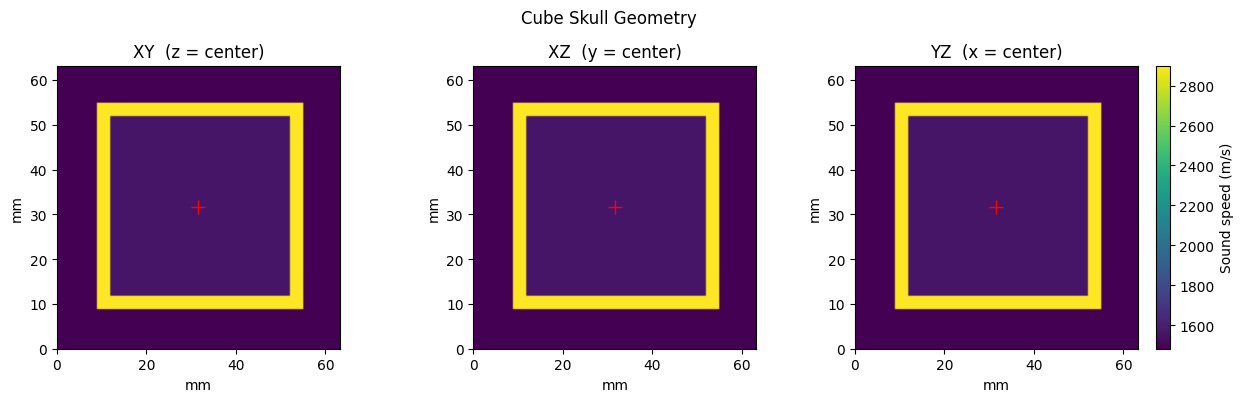

In [5]:
# Build heterogeneous medium
sound_speed_map = np.full((Nx, Ny, Nz), c_water,   dtype=np.float32)
density_map     = np.full((Nx, Ny, Nz), rho_water, dtype=np.float32)

sound_speed_map[skull_mask] = c_skull;  density_map[skull_mask] = rho_skull
sound_speed_map[brain_mask] = c_brain;  density_map[brain_mask] = rho_brain

medium = kWaveMedium(sound_speed=sound_speed_map, density=density_map)

# Geometry sanity check
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
kw = dict(origin='lower', cmap='viridis', vmin=c_water, vmax=c_skull,
          extent=[0, N*dx*1e3, 0, N*dx*1e3])

axes[0].imshow(sound_speed_map[:, :, cz].T, **kw)
axes[0].set_title('XY  (z = center)')
axes[1].imshow(sound_speed_map[:, cy, :].T, **kw)
axes[1].set_title('XZ  (y = center)')
im = axes[2].imshow(sound_speed_map[cx, :, :].T, **kw)
axes[2].set_title('YZ  (x = center)')

for ax in axes:
    ax.set_xlabel('mm'); ax.set_ylabel('mm')
    ax.plot(cx*dx*1e3, cy*dx*1e3, 'r+', ms=10)

plt.colorbar(im, ax=axes[2], label='Sound speed (m/s)')
plt.suptitle('Cube Skull Geometry')
plt.tight_layout()
plt.show()

In [6]:
# Source: single point at center, 100 kPa tone burst
source = kSource()
source.p_mask = np.zeros((Nx, Ny, Nz), dtype=np.uint8)
source.p_mask[cx, cy, cz] = 1

burst    = tone_burst(1 / kgrid.dt, freq, 5).flatten()
source.p = (burst * 1e5).reshape(1, -1)

# Sensor: full-volume p_max
sensor = kSensor()
sensor.mask   = np.ones((Nx, Ny, Nz), dtype=np.uint8)
sensor.record = ['p_max']

print(f'Source : point at ({cx}, {cy}, {cz})')
print(f'Burst  : {len(burst)} samples, amplitude 100 kPa')

Source : point at (64, 64, 64)
Burst  : 196 samples, amplitude 100 kPa


In [7]:
print('Running 3D k-Wave on GPU ...')
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor,
                               device='gpu', dtype='float32')

p_max = sensor_data['p_max'].reshape(Nx, Ny, Nz)

if np.isnan(p_max).any():
    print('WARNING: NaN in output')
else:
    print('Simulation OK')
    print(f'Peak pressure overall : {np.max(p_max)/1e3:.1f} kPa')
    print(f'Peak pressure in brain: {np.max(p_max[brain_mask])/1e3:.1f} kPa')

Running 3D k-Wave on GPU ...


k-Wave: 100%|██████████| 740/740 [00:13<00:00, 55.40step/s]


Simulation OK
Peak pressure overall : 33.2 kPa
Peak pressure in brain: 33.2 kPa


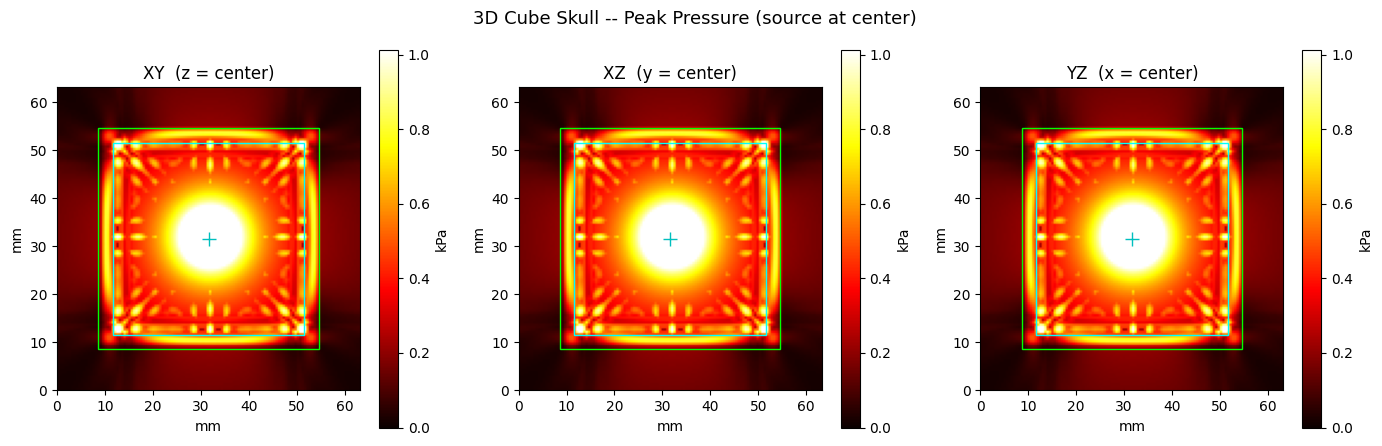

Saved to 3d_cube_skull_pmax.png


In [8]:
# Visualise: three orthogonal p_max slices
vmax_kpa = np.percentile(p_max, 99.5) / 1e3
extent_mm = [0, N*dx*1e3, 0, N*dx*1e3]

slices = [
    (p_max[:, :, cz].T / 1e3, 'XY  (z = center)'),
    (p_max[:, cy, :].T / 1e3, 'XZ  (y = center)'),
    (p_max[cx, :, :].T / 1e3, 'YZ  (x = center)'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (data, title) in zip(axes, slices):
    im = ax.imshow(data, origin='lower', extent=extent_mm,
                   cmap='hot', vmin=0, vmax=vmax_kpa)
    ax.set_title(title)
    ax.set_xlabel('mm'); ax.set_ylabel('mm')
    ax.plot(cx*dx*1e3, cy*dx*1e3, 'c+', ms=10)
    plt.colorbar(im, ax=ax, label='kPa')
    # skull boundary rectangles
    for r_mm, color in [(brain_half_mm, 'cyan'),
                        (brain_half_mm + skull_thick_mm, 'lime')]:
        c_mm = cx * dx * 1e3
        rect = plt.Rectangle((c_mm - r_mm, c_mm - r_mm), 2*r_mm, 2*r_mm,
                              lw=1, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

plt.suptitle('3D Cube Skull -- Peak Pressure (source at center)', fontsize=13)
plt.tight_layout()
plt.savefig('3d_cube_skull_pmax.png', dpi=150)
plt.show()
print('Saved to 3d_cube_skull_pmax.png')

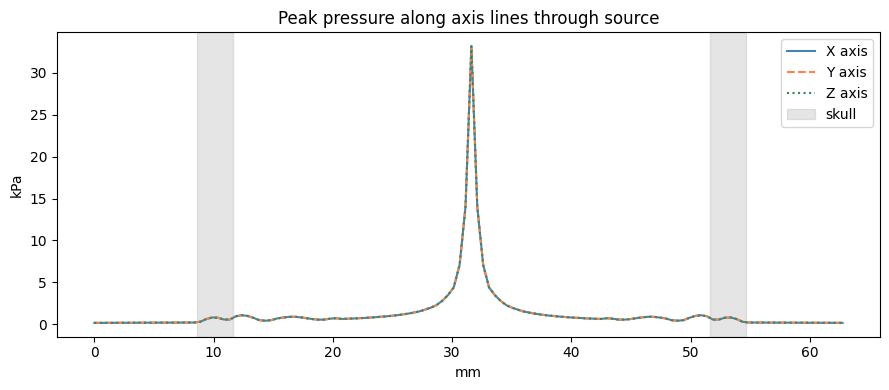

In [9]:
# 1-D pressure profiles along each axis through center
x_mm = np.arange(N) * dx * 1e3
c_mm = cx * dx * 1e3

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_mm, p_max[:, cy, cz] / 1e3, label='X axis', color='steelblue')
ax.plot(x_mm, p_max[cx, :, cz] / 1e3, label='Y axis', color='coral',   ls='--')
ax.plot(x_mm, p_max[cx, cy, :] / 1e3, label='Z axis', color='seagreen', ls=':')

# shade skull walls
for sign in [-1, 1]:
    lo = c_mm + sign * (brain_half_mm + skull_thick_mm)
    hi = c_mm + sign * brain_half_mm
    ax.axvspan(min(lo, hi), max(lo, hi), alpha=0.2, color='gray',
               label='skull' if sign == 1 else None)

ax.set_xlabel('mm')
ax.set_ylabel('kPa')
ax.set_title('Peak pressure along axis lines through source')
ax.legend()
plt.tight_layout()
plt.show()

## Sphere Skull
Same grid, source, and sensor as the cube test -- only the geometry changes.  
Geometry uses L2 (Euclidean) distance from center, so isocontours are spheres.

In [10]:
# Sphere skull geometry (reuse II, JJ, KK meshgrid arrays from cube section)
brain_radius_mm  = 20.0   # inner sphere radius (brain surface), mm
skull_thick_mm_s =  3.0   # skull wall thickness, mm

brain_radius_px  = brain_radius_mm                        * 1e-3 / dx
skull_outer_px_s = (brain_radius_mm + skull_thick_mm_s)   * 1e-3 / dx

# Euclidean (L2) distance from center -> sphere isocontours
R = np.sqrt(II**2 + JJ**2 + KK**2)

brain_mask_sph = R <  brain_radius_px
skull_mask_sph = (R >= brain_radius_px) & (R < skull_outer_px_s)

print(f'Brain radius : {brain_radius_mm:.1f} mm  ({brain_radius_px:.1f} px)')
print(f'Skull outer  : {brain_radius_mm + skull_thick_mm_s:.1f} mm  ({skull_outer_px_s:.1f} px)')
print(f'Water padding: {(N/2 - skull_outer_px_s) * dx * 1e3:.1f} mm each side')
print(f'Brain voxels : {brain_mask_sph.sum():,}')
print(f'Skull voxels : {skull_mask_sph.sum():,}')

Brain radius : 20.0 mm  (40.5 px)
Skull outer  : 23.0 mm  (46.6 px)
Water padding: 8.6 mm each side


Brain voxels : 278,177
Skull voxels : 144,324


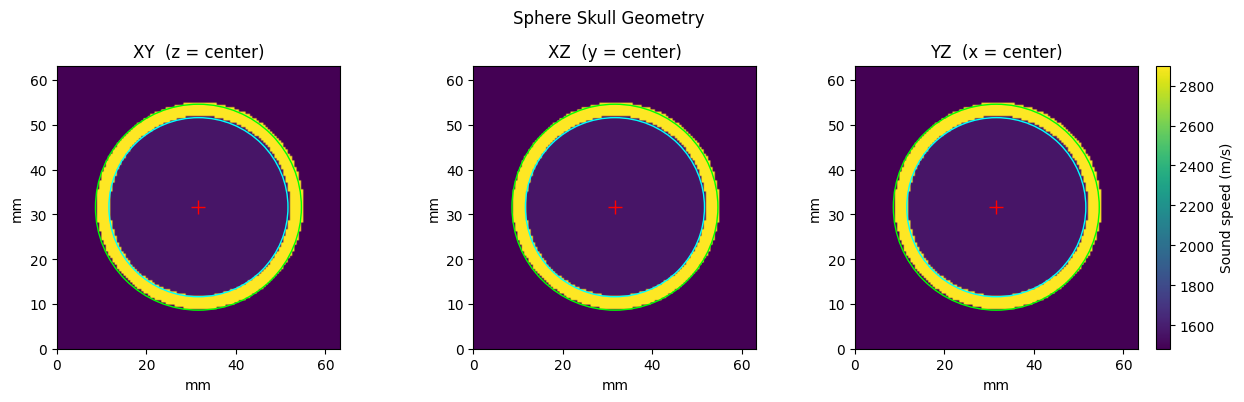

In [11]:
sound_speed_sph = np.full((Nx, Ny, Nz), c_water,   dtype=np.float32)
density_sph     = np.full((Nx, Ny, Nz), rho_water, dtype=np.float32)

sound_speed_sph[skull_mask_sph] = c_skull;  density_sph[skull_mask_sph] = rho_skull
sound_speed_sph[brain_mask_sph] = c_brain;  density_sph[brain_mask_sph] = rho_brain

medium_sph = kWaveMedium(sound_speed=sound_speed_sph, density=density_sph)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
kw = dict(origin='lower', cmap='viridis', vmin=c_water, vmax=c_skull,
          extent=[0, N*dx*1e3, 0, N*dx*1e3])
axes[0].imshow(sound_speed_sph[:, :, cz].T, **kw)
axes[0].set_title('XY  (z = center)')
axes[1].imshow(sound_speed_sph[:, cy, :].T, **kw)
axes[1].set_title('XZ  (y = center)')
im = axes[2].imshow(sound_speed_sph[cx, :, :].T, **kw)
axes[2].set_title('YZ  (x = center)')

c_mm = cx * dx * 1e3
for ax in axes:
    ax.set_xlabel('mm'); ax.set_ylabel('mm')
    ax.plot(c_mm, c_mm, 'r+', ms=10)
    for r_mm, color in [(brain_radius_mm, 'cyan'),
                        (brain_radius_mm + skull_thick_mm_s, 'lime')]:
        circle = plt.Circle((c_mm, c_mm), r_mm, lw=1, edgecolor=color, facecolor='none')
        ax.add_patch(circle)

plt.colorbar(im, ax=axes[2], label='Sound speed (m/s)')
plt.suptitle('Sphere Skull Geometry')
plt.tight_layout()
plt.show()

In [12]:
# Source and sensor are identical to the cube test (point at center, full-volume p_max)
print('Running sphere skull on GPU ...')
sensor_data_sph = kspaceFirstOrder(kgrid, medium_sph, source, sensor,
                                   device='gpu', dtype='float32')

p_max_sph = sensor_data_sph['p_max'].reshape(Nx, Ny, Nz)

if np.isnan(p_max_sph).any():
    print('WARNING: NaN in output')
else:
    print('Simulation OK')
    print(f'Peak pressure overall : {np.max(p_max_sph)/1e3:.1f} kPa')
    print(f'Peak pressure in brain: {np.max(p_max_sph[brain_mask_sph])/1e3:.1f} kPa')

Running sphere skull on GPU ...


k-Wave: 100%|██████████| 740/740 [00:13<00:00, 55.42step/s]


Simulation OK
Peak pressure overall : 33.2 kPa
Peak pressure in brain: 33.2 kPa


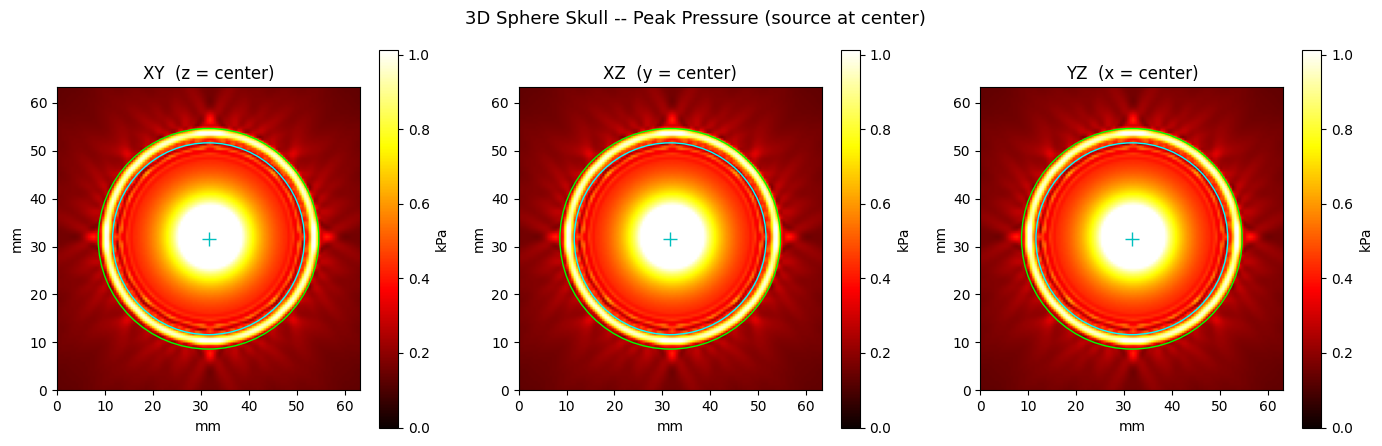

Saved to 3d_sphere_skull_pmax.png


In [13]:
vmax_kpa_s = np.percentile(p_max_sph, 99.5) / 1e3
extent_mm = [0, N*dx*1e3, 0, N*dx*1e3]

slices = [
    (p_max_sph[:, :, cz].T / 1e3, 'XY  (z = center)'),
    (p_max_sph[:, cy, :].T / 1e3, 'XZ  (y = center)'),
    (p_max_sph[cx, :, :].T / 1e3, 'YZ  (x = center)'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
c_mm = cx * dx * 1e3
for ax, (data, title) in zip(axes, slices):
    im = ax.imshow(data, origin='lower', extent=extent_mm,
                   cmap='hot', vmin=0, vmax=vmax_kpa_s)
    ax.set_title(title)
    ax.set_xlabel('mm'); ax.set_ylabel('mm')
    ax.plot(c_mm, c_mm, 'c+', ms=10)
    plt.colorbar(im, ax=ax, label='kPa')
    for r_mm, color in [(brain_radius_mm, 'cyan'),
                        (brain_radius_mm + skull_thick_mm_s, 'lime')]:
        circle = plt.Circle((c_mm, c_mm), r_mm, lw=1, edgecolor=color, facecolor='none')
        ax.add_patch(circle)

plt.suptitle('3D Sphere Skull -- Peak Pressure (source at center)', fontsize=13)
plt.tight_layout()
plt.savefig('3d_sphere_skull_pmax.png', dpi=150)
plt.show()
print('Saved to 3d_sphere_skull_pmax.png')

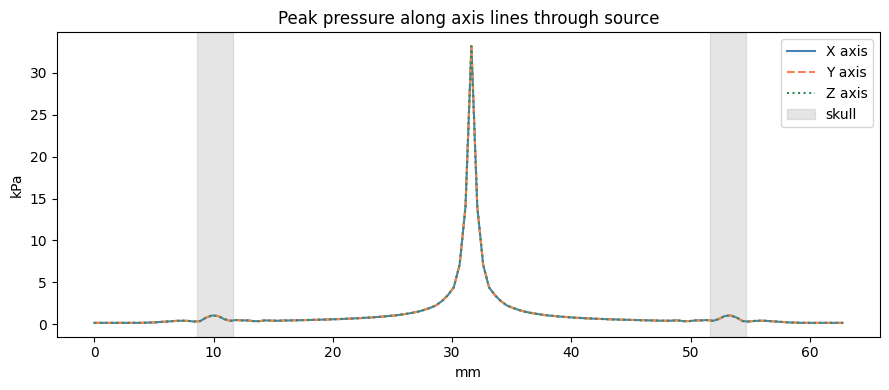

In [18]:
x_mm = np.arange(N) * dx * 1e3
c_mm = cx * dx * 1e3

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_mm, p_max_sph[:, cy, cz] / 1e3, label='X axis', color='steelblue')
ax.plot(x_mm, p_max_sph[cx, :, cz] / 1e3, label='Y axis', color='coral',   ls='--')
ax.plot(x_mm, p_max_sph[cx, cy, :] / 1e3, label='Z axis', color='seagreen', ls=':')

for sign in [-1, 1]:
    lo = c_mm + sign * (brain_radius_mm + skull_thick_mm_s)
    hi = c_mm + sign * brain_radius_mm
    ax.axvspan(min(lo, hi), max(lo, hi), alpha=0.2, color='gray',
               label='skull' if sign == 1 else None)

ax.set_xlabel('mm')
ax.set_ylabel('kPa')
ax.set_title('Peak pressure along axis lines through source')
ax.legend()
plt.tight_layout()
plt.show()

## NIfTI Skull Mask
Load the real skull segmentation (`skull_mask.nii`, 0.5 mm isotropic, binary), crop a manageable sub-volume centred on the skull, infer the brain interior by slice-wise hole-filling, and build a heterogeneous `kWaveMedium` from it.

| Tissue | c (m/s) | ρ (kg/m³) |
|--------|---------|-----------|
| Water  | 1482    | 1000      |
| Skull  | 2900    | 1900      |
| Brain  | 1560    | 1040      |

import nibabel as nib
from scipy import ndimage

# ── Load skull mask ──────────────────────────────────────────────────────────
skull_nii  = nib.load(r'C:\Users\bengi\Documents\Pesaran Lab\skull_mask_2.nii')
skull_raw  = skull_nii.get_fdata().astype(bool)
vox_mm     = np.array(skull_nii.header.get_zooms()[:3])
dx_nii     = float(vox_mm[0]) * 1e-3   # 0.5 mm → 0.0005 m

# ── Load brain mask — resample to skull space if affines differ ───────────────
brain_nii_file = nib.load(r'C:\Users\bengi\Documents\Pesaran Lab\brain_mask.nii')

print(f'Skull : shape={skull_raw.shape}   voxel={vox_mm} mm')
print(f'Brain : shape={brain_nii_file.shape}')
print(f'\nSkull affine:\n{skull_nii.affine}')
print(f'\nBrain affine:\n{brain_nii_file.affine}')

if np.allclose(skull_nii.affine, brain_nii_file.affine, atol=1e-3):
    print('\nAffines match — using brain mask as-is.')
    brain_raw = brain_nii_file.get_fdata().astype(bool)
else:
    print('\nAffine mismatch — resampling brain into skull coordinate space ...')
    from nibabel.processing import resample_from_to
    brain_in_skull = resample_from_to(brain_nii_file, skull_nii, order=0)
    brain_raw = brain_in_skull.get_fdata().astype(bool)
    print(f'Resampled brain shape : {brain_raw.shape}')

# ── Pad Z to 256 if needed ───────────────────────────────────────────────────
target_z  = max(256, skull_raw.shape[2])
pad_total = target_z - skull_raw.shape[2]
pad_lo    = pad_total // 2
pad_hi    = pad_total - pad_lo

skull_pad = np.pad(skull_raw, ((0,0),(0,0),(pad_lo, pad_hi)), mode='constant')
brain_pad = np.pad(brain_raw, ((0,0),(0,0),(pad_lo, pad_hi)), mode='constant')
brain_pad = brain_pad & ~skull_pad   # resolve any skull–brain overlap

print(f'\nAfter Z-padding: skull {skull_pad.shape},  brain {brain_pad.shape}')
print(f'Skull voxels : {skull_pad.sum():,}')
print(f'Brain voxels : {brain_pad.sum():,}')
print(f'Water voxels : {(~skull_pad & ~brain_pad).sum():,}')

### Step 2 — Assign Brain Mask & Geometry Checks
Assigns the loaded brain mask and runs bbox/overlap sanity checks, a 2D colour-coded tissue map, and a 3D skull surface render.

In [ ]:
import nibabel as nib
from scipy import ndimage

# ── Load skull mask ──────────────────────────────────────────────────────────
skull_nii  = nib.load(r'C:\Users\bengi\Documents\Pesaran Lab\skull_mask.nii')
skull_raw  = skull_nii.get_fdata().astype(bool)
vox_mm     = np.array(skull_nii.header.get_zooms()[:3])
dx_nii     = float(vox_mm[0]) * 1e-3   # 0.5 mm → 0.0005 m

# ── Load brain mask — resample to skull space if affines differ ───────────────
brain_nii_file = nib.load(r'C:\Users\bengi\Documents\Pesaran Lab\brain_mask.nii')

print(f'Skull : shape={skull_raw.shape}   voxel={vox_mm} mm')
print(f'Brain : shape={brain_nii_file.shape}')
print(f'\nSkull affine:\n{skull_nii.affine}')
print(f'\nBrain affine:\n{brain_nii_file.affine}')

if np.allclose(skull_nii.affine, brain_nii_file.affine, atol=1e-3):
    print('\nAffines match — using brain mask as-is.')
    brain_raw = brain_nii_file.get_fdata().astype(bool)
else:
    print('\nAffine mismatch — resampling brain into skull coordinate space ...')
    from nibabel.processing import resample_from_to
    brain_in_skull = resample_from_to(brain_nii_file, skull_nii, order=0)
    brain_raw = brain_in_skull.get_fdata().astype(bool)
    print(f'Resampled brain shape : {brain_raw.shape}')

# ── Pad Z from 208 → 256 to get a cubic 256³ grid ───────────────────────────
pad_total = 256 - skull_raw.shape[2]
pad_lo    = pad_total // 2
pad_hi    = pad_total - pad_lo

skull_pad = np.pad(skull_raw, ((0,0),(0,0),(pad_lo, pad_hi)), mode='constant')
brain_pad = np.pad(brain_raw, ((0,0),(0,0),(pad_lo, pad_hi)), mode='constant')
brain_pad = brain_pad & ~skull_pad   # resolve any skull–brain overlap

print(f'\nAfter Z-padding: skull {skull_pad.shape},  brain {brain_pad.shape}')
print(f'Skull voxels : {skull_pad.sum():,}')
print(f'Brain voxels : {brain_pad.sum():,}')
print(f'Water voxels : {(~skull_pad & ~brain_pad).sum():,}')

In [20]:
# ── Use the 3D-Slicer brain mask directly ────────────────────────────────────
brain_nii = brain_pad   # real segmentation, no fill needed

# Sanity checks
assert brain_nii.shape == skull_pad.shape, "Shape mismatch between brain and skull masks"
overlap = (brain_nii & skull_pad).sum()
print(f'Brain–skull voxel overlap : {overlap}  (should be 0)')
print(f'Brain voxels  : {brain_nii.sum():,}')
print(f'Skull voxels  : {skull_pad.sum():,}')

# Check brain bbox is inside skull bbox
b_idx = np.argwhere(brain_nii)
s_idx = np.argwhere(skull_pad)
for ax, name in enumerate(['X','Y','Z']):
    b_lo, b_hi = b_idx[:,ax].min(), b_idx[:,ax].max()
    s_lo, s_hi = s_idx[:,ax].min(), s_idx[:,ax].max()
    status = 'OK' if b_lo >= s_lo and b_hi <= s_hi else 'WARNING'
    print(f'  {name}: brain=[{b_lo}–{b_hi}]  skull=[{s_lo}–{s_hi}]  {status}')

Brain–skull voxel overlap : 0  (should be 0)
Brain voxels  : 11,989,107
Skull voxels  : 905,935
  X: brain=[0–255]  skull=[20–228]  WARNING
  Y: brain=[0–252]  skull=[0–244]  WARNING
  Z: brain=[24–231]  skull=[32–222]  WARNING


### Step 3 — Build k-Wave Grid & Medium
Creates the 256³ `kWaveGrid` at 0.5 mm and fills the `kWaveMedium` with water/skull/brain sound speeds and densities.

Skull bbox : x=[20–228]  y=[0–244]  z=[32–222]
Diagnostic slice : (124, 122, 127)  →  (62, 61, 64) mm


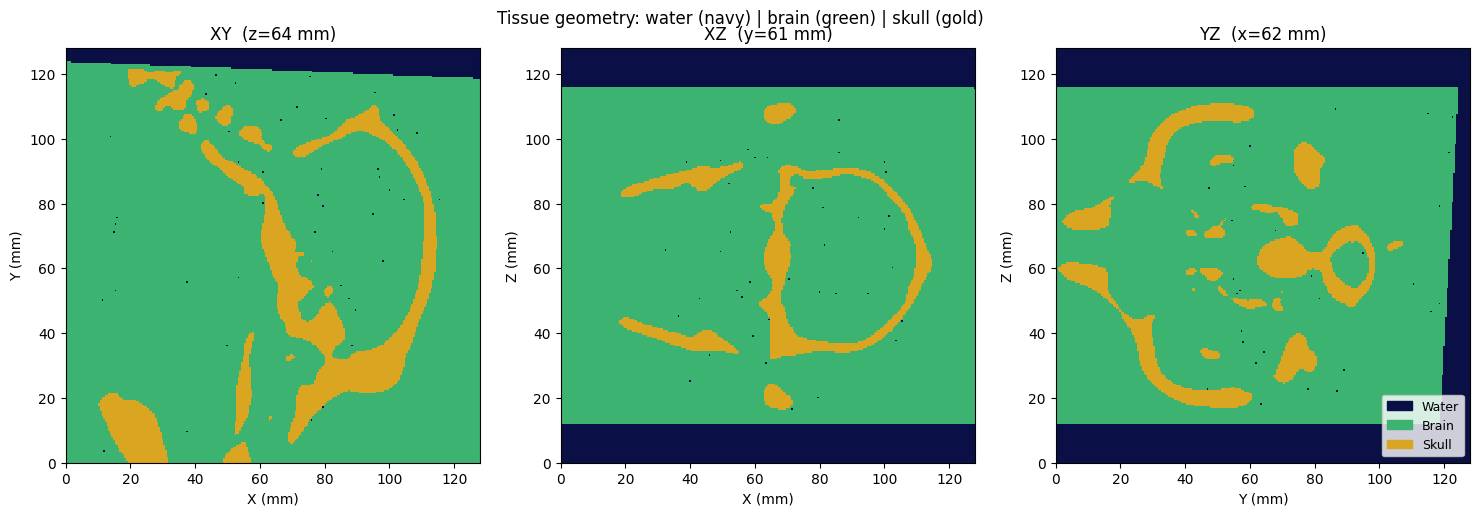

Saved 3d_nifti_tissue_check.png


In [24]:
# ── Diagnostic: skull / brain / water geometry check ─────────────────────────
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Extents for imshow (mm)
_Nx, _Ny, _Nz = skull_pad.shape
_ex = [0, _Nx * dx_nii * 1e3]
_ey = [0, _Ny * dx_nii * 1e3]
_ez = [0, _Nz * dx_nii * 1e3]

tissue_map = np.zeros(skull_pad.shape, dtype=np.uint8)  # 0 = water
tissue_map[brain_nii] = 1                               # 1 = brain
tissue_map[skull_pad] = 2                               # 2 = skull

# Slice through the bounding-box centre of the skull
sk_idx = np.argwhere(skull_pad)
cxd = int((sk_idx[:,0].min() + sk_idx[:,0].max()) // 2)
cyd = int((sk_idx[:,1].min() + sk_idx[:,1].max()) // 2)
czd = int((sk_idx[:,2].min() + sk_idx[:,2].max()) // 2)
print(f'Skull bbox : x=[{sk_idx[:,0].min()}–{sk_idx[:,0].max()}]  '
      f'y=[{sk_idx[:,1].min()}–{sk_idx[:,1].max()}]  '
      f'z=[{sk_idx[:,2].min()}–{sk_idx[:,2].max()}]')
print(f'Diagnostic slice : ({cxd}, {cyd}, {czd})  →  '
      f'({cxd*dx_nii*1e3:.0f}, {cyd*dx_nii*1e3:.0f}, {czd*dx_nii*1e3:.0f}) mm')

cmap3 = ListedColormap(['#0a1045', '#3cb371', '#daa520'])  # water, brain, skull
kw_t  = dict(origin='lower', cmap=cmap3, vmin=0, vmax=2, interpolation='nearest')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(tissue_map[:, :, czd].T, extent=_ex + _ey, **kw_t)
axes[0].set(title=f'XY  (z={czd*dx_nii*1e3:.0f} mm)', xlabel='X (mm)', ylabel='Y (mm)')

axes[1].imshow(tissue_map[:, cyd, :].T, extent=_ex + _ez, **kw_t)
axes[1].set(title=f'XZ  (y={cyd*dx_nii*1e3:.0f} mm)', xlabel='X (mm)', ylabel='Z (mm)')

im_t = axes[2].imshow(tissue_map[cxd, :, :].T, extent=_ey + _ez, **kw_t)
axes[2].set(title=f'YZ  (x={cxd*dx_nii*1e3:.0f} mm)', xlabel='Y (mm)', ylabel='Z (mm)')

legend_patches = [Patch(color='#0a1045', label='Water'),
                  Patch(color='#3cb371', label='Brain'),
                  Patch(color='#daa520', label='Skull')]
axes[2].legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.suptitle('Tissue geometry: water (navy) | brain (green) | skull (gold)', fontsize=12)
plt.tight_layout()
plt.savefig('3d_nifti_tissue_check.png', dpi=150)
plt.show()
print('Saved 3d_nifti_tissue_check.png')

### Step 4 — Point Source & 3-Plane Sensor
Places a 100 kPa, 5-cycle, 500 kHz tone-burst source at the brain centroid. Sensor records p_max on three orthogonal planes through the source (~1.2 GB GPU, vs ~99 GB for full volume).

### Step 5 — Run Simulation (GPU)
Runs `kspaceFirstOrder` on GPU. Expected time ~2–5 min for 256³ / 1479 steps on RTX 5070. Output `sd_nii['p_max']` is 1-D; mapped back to 3-D via the sensor mask.

### Step 6 — Visualize Peak Pressure
Plots p_max on the 3 sensor planes with skull contour (cyan) and source location (white +) overlaid.

Skull surface mesh: 91,118 vertices, 182,830 faces


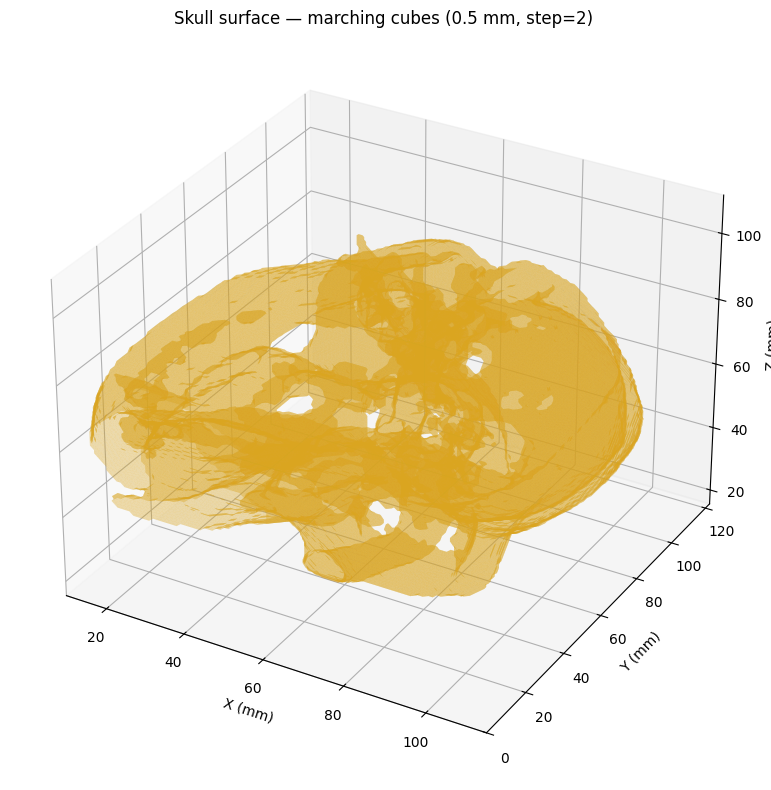

Saved 3d_skull_surface.png


In [23]:
# ── 3D skull surface (marching cubes) ────────────────────────────────────────
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# step_size=2 halves the resolution but cuts face count ~8x (still accurate enough)
verts, faces, _, _ = measure.marching_cubes(skull_pad.astype(np.float32),
                                             level=0.5, step_size=2)
verts_mm = verts * dx_nii * 1e3   # convert voxels → mm

print(f'Skull surface mesh: {len(verts_mm):,} vertices, {len(faces):,} faces')

fig = plt.figure(figsize=(9, 8))
ax  = fig.add_subplot(111, projection='3d')

mesh = Poly3DCollection(verts_mm[faces], alpha=0.4, linewidth=0)
mesh.set_facecolor('goldenrod')
mesh.set_edgecolor('none')
ax.add_collection3d(mesh)

ax.set_xlim(verts_mm[:,0].min(), verts_mm[:,0].max())
ax.set_ylim(verts_mm[:,1].min(), verts_mm[:,1].max())
ax.set_zlim(verts_mm[:,2].min(), verts_mm[:,2].max())
ax.set_xlabel('X (mm)');  ax.set_ylabel('Y (mm)');  ax.set_zlabel('Z (mm)')
ax.set_title('Skull surface — marching cubes (0.5 mm, step=2)')

plt.tight_layout()
plt.savefig('3d_skull_surface.png', dpi=150)
plt.show()
print('Saved 3d_skull_surface.png')

In [ ]:
# ── k-Wave grid and medium ───────────────────────────────────────────────────
Nx_n, Ny_n, Nz_n = skull_pad.shape   # 256, 256, 256

kgrid_nii = kWaveGrid([Nx_n, Ny_n, Nz_n], [dx_nii, dx_nii, dx_nii])
kgrid_nii.makeTime(c_skull, cfl=0.3)

print(f'Grid        : {Nx_n}×{Ny_n}×{Nz_n} = {Nx_n*Ny_n*Nz_n/1e6:.1f} M points')
print(f'Physical    : {Nx_n*dx_nii*1e3:.0f} × {Ny_n*dx_nii*1e3:.0f} × {Nz_n*dx_nii*1e3:.0f} mm')
print(f'dx          : {dx_nii*1e3:.2f} mm  ({c_water / (dx_nii * freq):.1f} pts/wavelength at 500 kHz)')
print(f'dt = {kgrid_nii.dt:.3e} s,  Nt = {kgrid_nii.Nt}')

# Build heterogeneous medium
ss_nii  = np.full((Nx_n, Ny_n, Nz_n), c_water,   dtype=np.float32)
rho_nii = np.full((Nx_n, Ny_n, Nz_n), rho_water, dtype=np.float32)

ss_nii[skull_pad]  = c_skull;   rho_nii[skull_pad]  = rho_skull
ss_nii[brain_nii]  = c_brain;   rho_nii[brain_nii]  = rho_brain

medium_nii = kWaveMedium(sound_speed=ss_nii, density=rho_nii)

print(f'\nMedium built — sound speed range: {ss_nii.min():.0f}–{ss_nii.max():.0f} m/s')

Grid        : 256×256×256 = 16.8 M points
Physical    : 128 × 128 × 128 mm
dx          : 0.50 mm  (5.9 pts/wavelength at 500 kHz)
dt = 5.172e-08 s,  Nt = 1479

Medium built — sound speed range: 1482–2900 m/s


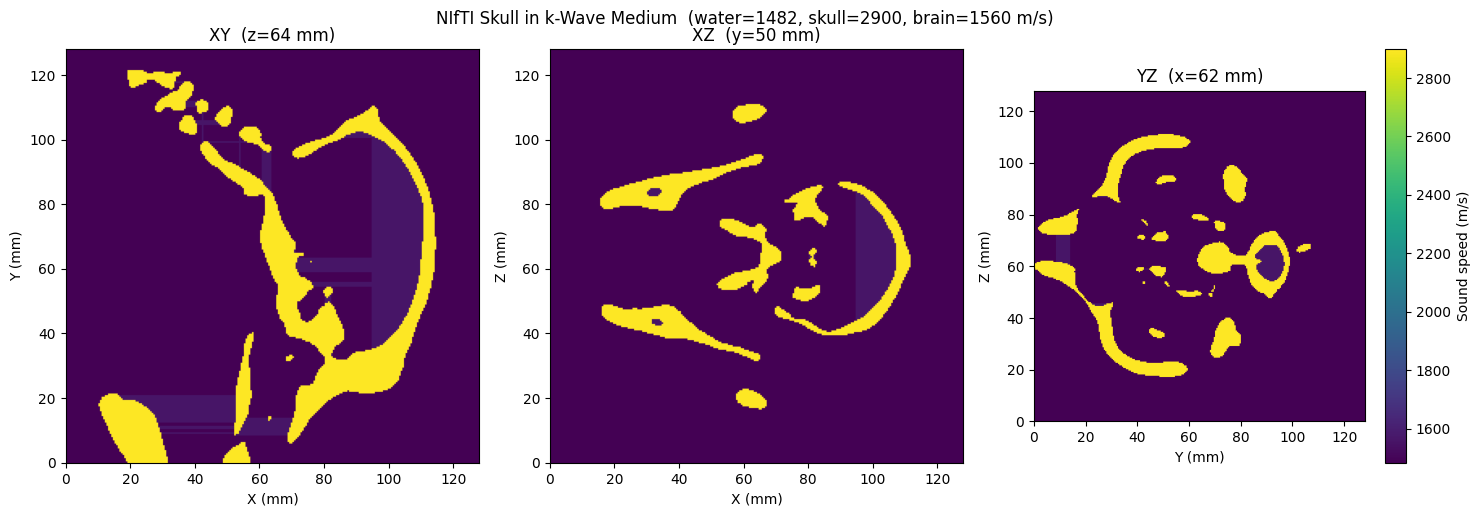

Saved to 3d_nifti_skull_geometry.png

Summary:
  Grid   : 256×256×256  (128×128×128 mm)
  Skull  : 905,935 voxels
  Brain  : 330,496 voxels
  dt     : 5.172e-08 s,  Nt = 1479


In [ ]:
# ── Visualise geometry: three orthogonal slices through skull centre ─────────
# Use the bounding-box centre of the skull (in the padded volume)
nz_idx = np.argwhere(skull_pad)
cx_n = int(nz_idx[:, 0].mean())
cy_n = int(nz_idx[:, 1].mean())
cz_n = int(nz_idx[:, 2].mean())

ext_x = [0, Nx_n * dx_nii * 1e3]
ext_y = [0, Ny_n * dx_nii * 1e3]
ext_z = [0, Nz_n * dx_nii * 1e3]

kw = dict(origin='lower', cmap='viridis', vmin=c_water, vmax=c_skull)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(ss_nii[:, :, cz_n].T, extent=ext_x+ext_y, **kw)
axes[0].set(title=f'XY  (z={cz_n*dx_nii*1e3:.0f} mm)', xlabel='X (mm)', ylabel='Y (mm)')

im1 = axes[1].imshow(ss_nii[:, cy_n, :].T, extent=ext_x+ext_z, **kw)
axes[1].set(title=f'XZ  (y={cy_n*dx_nii*1e3:.0f} mm)', xlabel='X (mm)', ylabel='Z (mm)')

im2 = axes[2].imshow(ss_nii[cx_n, :, :].T, extent=ext_y+ext_z, **kw)
axes[2].set(title=f'YZ  (x={cx_n*dx_nii*1e3:.0f} mm)', xlabel='Y (mm)', ylabel='Z (mm)')

plt.colorbar(im2, ax=axes[2], label='Sound speed (m/s)')
plt.suptitle('NIfTI Skull in k-Wave Medium  (water=1482, skull=2900, brain=1560 m/s)', fontsize=12)
plt.tight_layout()
plt.savefig('3d_nifti_skull_geometry.png', dpi=150)
plt.show()
print('Saved to 3d_nifti_skull_geometry.png')
print(f'\nSummary:')
print(f'  Grid   : {Nx_n}×{Ny_n}×{Nz_n}  ({Nx_n*dx_nii*1e3:.0f}×{Ny_n*dx_nii*1e3:.0f}×{Nz_n*dx_nii*1e3:.0f} mm)')
print(f'  Skull  : {skull_pad.sum():,} voxels')
print(f'  Brain  : {brain_nii.sum():,} voxels')
print(f'  dt     : {kgrid_nii.dt:.3e} s,  Nt = {kgrid_nii.Nt}')

In [ ]:
# ── Point source at brain centroid ───────────────────────────────────────────
brain_com = ndimage.center_of_mass(brain_nii)
sx = int(round(brain_com[0]))
sy = int(round(brain_com[1]))
sz = int(round(brain_com[2]))

assert brain_nii[sx, sy, sz], "Source voxel not inside brain — adjust centroid"

source_nii = kSource()
source_nii.p_mask = np.zeros((Nx_n, Ny_n, Nz_n), dtype=np.uint8)
source_nii.p_mask[sx, sy, sz] = 1

burst_nii = tone_burst(1 / kgrid_nii.dt, freq, 5).flatten()
source_nii.p = (burst_nii * 1e5).reshape(1, -1)   # 100 kPa amplitude

# ── 3-plane sensor (XY / XZ / YZ through source) ────────────────────────────
# Full-volume sensor at 256³ requires ~99 GB to store p(t) for all points.
# Three orthogonal planes cost only ~1.2 GB — enough for visualisation.
sensor_mask_3pl = np.zeros((Nx_n, Ny_n, Nz_n), dtype=np.uint8)
sensor_mask_3pl[:, :, sz] = 1   # XY plane
sensor_mask_3pl[:, sy, :] = 1   # XZ plane
sensor_mask_3pl[sx, :, :] = 1   # YZ plane

sensor_nii = kSensor()
sensor_nii.mask   = sensor_mask_3pl
sensor_nii.record = ['p_max']

n_sensor = int(sensor_mask_3pl.sum())
mem_GB = n_sensor * kgrid_nii.Nt * 4 / 1e9

print(f'Brain centroid : ({brain_com[0]:.1f}, {brain_com[1]:.1f}, {brain_com[2]:.1f})')
print(f'Source voxel   : ({sx}, {sy}, {sz})  →  ({sx*dx_nii*1e3:.1f}, {sy*dx_nii*1e3:.1f}, {sz*dx_nii*1e3:.1f}) mm')
print(f'Sensor points  : {n_sensor:,}  (3 planes, estimated GPU mem ≈ {mem_GB:.2f} GB)')
print(f'Burst          : {len(burst_nii)} samples @ 500 kHz, 5 cycles, 100 kPa')

Brain centroid : (168.6, 118.5, 126.2)
Source voxel   : (169, 119, 126)  →  (84.5, 59.5, 63.0) mm
Sensor points  : 195,841  (3 planes, estimated GPU mem ≈ 1.16 GB)
Burst          : 194 samples @ 500 kHz, 5 cycles, 100 kPa


In [ ]:
print('Running NIfTI skull + point source on GPU  (256³, Nt=1479, 3-plane sensor) ...')
sd_nii = kspaceFirstOrder(kgrid_nii, medium_nii, source_nii, sensor_nii,
                           device='gpu', dtype='float32')

# Sensor output is 1D (n_sensor_points,) — put back into a 3D volume via the mask
p_max_nii = np.zeros((Nx_n, Ny_n, Nz_n), dtype=np.float32)
p_max_nii[sensor_mask_3pl.astype(bool)] = sd_nii['p_max']

if np.isnan(p_max_nii[sensor_mask_3pl.astype(bool)]).any():
    print('WARNING: NaN detected')
else:
    print('Simulation OK')
    print(f'Peak pressure (3 planes) : {p_max_nii.max()/1e3:.1f} kPa')
    print(f'Peak pressure XY plane   : {p_max_nii[:, :, sz].max()/1e3:.1f} kPa')
    print(f'Peak pressure XZ plane   : {p_max_nii[:, sy, :].max()/1e3:.1f} kPa')
    print(f'Peak pressure YZ plane   : {p_max_nii[sx, :, :].max()/1e3:.1f} kPa')

Running NIfTI skull + point source on GPU  (256³, Nt=1479, 3-plane sensor) ...


k-Wave:   0%|          | 0/1479 [00:00<?, ?step/s]


KeyboardInterrupt: 

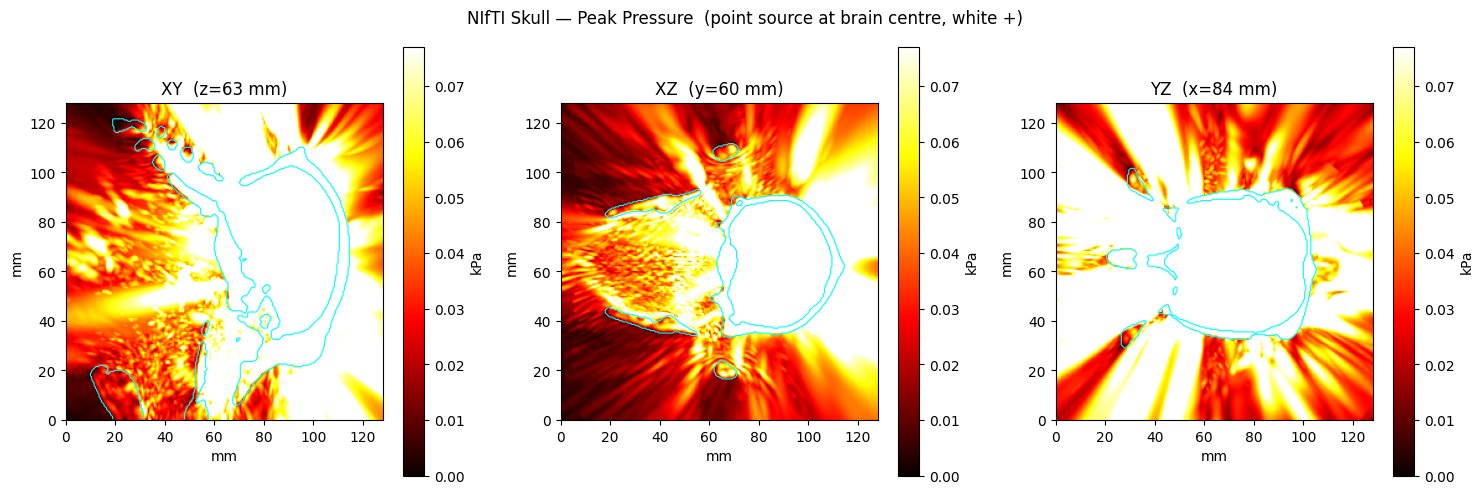

Saved to 3d_nifti_skull_pmax.png


In [ ]:
# ── Visualise p_max: three slices through source, skull contour overlaid ─────
vmax_kpa_n = np.percentile(p_max_nii, 99.5) / 1e3

sx_mm = sx * dx_nii * 1e3
sy_mm = sy * dx_nii * 1e3
sz_mm = sz * dx_nii * 1e3

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

panels = [
    (p_max_nii[:, :, sz].T / 1e3,  ext_x + ext_y,  f'XY  (z={sz_mm:.0f} mm)',  sx_mm, sy_mm,  skull_pad[:, :, sz].T),
    (p_max_nii[:, sy, :].T / 1e3,  ext_x + ext_z,  f'XZ  (y={sy_mm:.0f} mm)',  sx_mm, sz_mm,  skull_pad[:, sy, :].T),
    (p_max_nii[sx, :, :].T / 1e3,  ext_y + ext_z,  f'YZ  (x={sx_mm:.0f} mm)',  sy_mm, sz_mm,  skull_pad[sx, :, :].T),
]

for ax, (data, ext, title, dot_x, dot_y, skull_sl) in zip(axes, panels):
    im = ax.imshow(data, origin='lower', extent=ext, cmap='hot',
                   vmin=0, vmax=vmax_kpa_n)
    ax.contour(skull_sl, levels=[0.5], colors='cyan', linewidths=0.8,
               extent=ext, origin='lower')
    ax.plot(dot_x, dot_y, 'w+', ms=10, mew=1.5)
    ax.set(title=title, xlabel='mm', ylabel='mm')
    plt.colorbar(im, ax=ax, label='kPa')

plt.suptitle('NIfTI Skull — Peak Pressure  (point source at brain centre, white +)',
             fontsize=12)
plt.tight_layout()
plt.savefig('3d_nifti_skull_pmax.png', dpi=150)
plt.show()
print('Saved to 3d_nifti_skull_pmax.png')